# Sesión 13: AJUSTE DE HIPERPARÁMETROS DE UN MODELO. ESTRATEGIAS DE COMPARACIÓN Y EVALUACIÓN DE DIFERENTES MODELOS

Realizado por:

**- [Ruelas Flores, César Diego](https://www.linkedin.com/in/diego-ruelas-flores/)**

- **Configuración del entorno:**

In [ ]:
#  %pip install ucimlrepo polars scikit-learn pytest matplotlib seaborn lxml pandas pytest-mock

## 1. VARIABLES GLOBALES

- Instalamos las librerías necesarias en el entorno del notebook

In [ ]:
import sys
import os
import polars as pl
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuración de la Ruta del Proyecto ---
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Proyecto raíz añadido al path: {project_root}")

Proyecto raíz añadido al path: c:\Users\AzShet\Documents\Jupyter_LAB\jupyter_projects\5to_ciclo\DataMining\lab13\Data_Mining-LAB13


- **Variables globales de configuración del proyecto**

In [5]:
TARGET_VARIABLE = "actual_productivity"
PRODUCTIVITY_THRESHOLD = 0.5
CATEGORICAL_FEATURES = ["day", "quarter", "department", "team"]
TEST_SIZE = 0.20
RANDOM_STATE = 42
# ID del dataset "Productivity Prediction of Garment Employees"
GARMENT_EMPLOYEES_ID = 597

## 2. FUNCIONES (../src/utils.py)

In [ ]:
%%writefile ../src/utils.py
import polars as pl
import numpy as np
from typing import List, Dict, Tuple, Any
from ucimlrepo import fetch_ucirepo
import polars.selectors as cs

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score

def load_and_prepare_data(dataset_id: int, target: str, threshold: float) -> pl.DataFrame:
    """Obtiene un dataset desde UCI, lo combina y realiza un preprocesamiento inicial.

    Esta función se conecta al Repositorio de Machine Learning de UCI para
    descargar un dataset por su ID. Combina los DataFrames de características (X)
    y objetivo (y) en un único DataFrame de Polars. Finalmente, elimina la
    columna 'date' y binariza la variable objetivo según un umbral.

    Args:
        dataset_id (int): El ID numérico del dataset en el Repositorio de UCI.
        target (str): El nombre de la columna objetivo que será binarizada.
        threshold (float): El punto de corte para la binarización. Los valores
            mayores o iguales al umbral se convierten en 1, y los menores en 0.

    Returns:
        pl.DataFrame: Un DataFrame de Polars que contiene los datos combinados
            y preparados para las siguientes etapas de preprocesamiento.
    """
    repo = fetch_ucirepo(id=dataset_id)
    X_pd = repo.data.features
    y_pd = repo.data.targets
    
    X_pl = pl.from_pandas(X_pd)
    y_pl = pl.from_pandas(y_pd)
    df = pl.concat([X_pl, y_pl], how="horizontal")

    df = df.drop("date")
    df = df.with_columns(
        pl.when(pl.col(target) >= threshold)
        .then(pl.lit(1, dtype=pl.Int32))
        .otherwise(pl.lit(0, dtype=pl.Int32))
        .alias(target)
    )
    return df

def handle_missing_values(df: pl.DataFrame) -> pl.DataFrame:
    """Imputa valores faltantes en columnas de tipo Float64 usando su mediana.

    Itera sobre todas las columnas de tipo Float64 en el DataFrame. Si una
    columna contiene valores nulos, calcula su mediana (ignorando los nulos)
    y la utiliza para rellenar dichos espacios vacíos.

    Args:
        df (pl.DataFrame): El DataFrame de Polars de entrada, posiblemente con
            valores nulos.

    Returns:
        pl.DataFrame: Un DataFrame de Polars sin valores nulos en sus columnas
            de tipo Float64.
    """
    for col_name in df.select(pl.col(pl.Float64)).columns:
        if df[col_name].is_null().any():
            median_val = df[col_name].median()
            df = df.with_columns(pl.col(col_name).fill_null(median_val))
    return df

def handle_multivariate_outliers(df: pl.DataFrame, contamination: float = 0.05) -> pl.DataFrame:
    """Identifica y elimina outliers multivariados usando Isolation Forest.

    Este método aplica el algoritmo Isolation Forest a las columnas numéricas
    del DataFrame para detectar observaciones que son anómalas en un contexto
    multivariado. Las filas identificadas como outliers son eliminadas.

    Args:
        df (pl.DataFrame): El DataFrame de Polars de entrada.
        contamination (float, optional): La proporción esperada de outliers
            en el conjunto de datos. Debe estar entre 0 y 0.5. Por defecto es 0.05.

    Returns:
        pl.DataFrame: Un nuevo DataFrame de Polars sin las filas que fueron
            clasificadas como outliers.
    """
    numeric_cols = df.select(cs.numeric()).columns
    numeric_data_np = df.select(numeric_cols).to_numpy()
    
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    outliers = iso_forest.fit_predict(numeric_data_np)
    
    df_with_preds = df.with_columns(pl.Series("outlier", outliers))
    return df_with_preds.filter(pl.col("outlier") == 1).drop("outlier")

def create_dummies(df: pl.DataFrame, cat_features: List[str]) -> pl.DataFrame:
    """Convierte columnas categóricas a variables dummy (One-Hot Encoding).

    Toma una lista de nombres de columnas y las transforma en formato numérico
    mediante one-hot encoding. Para evitar la multicolinealidad, se elimina
    la primera categoría de cada variable (`drop_first=True`).

    Args:
        df (pl.DataFrame): El DataFrame de Polars de entrada.
        cat_features (List[str]): Una lista con los nombres de las columnas
            categóricas que se van a convertir.

    Returns:
        pl.DataFrame: Un nuevo DataFrame donde las columnas categóricas han sido
            reemplazadas por sus representaciones numéricas dummy.
    """
    df = df.with_columns(pl.col('team').cast(pl.Utf8))
    return df.to_dummies(columns=cat_features, drop_first=True)

def split_data(df: pl.DataFrame, target: str, test_size: float, random_state: int) -> Tuple:
    """Divide los datos en conjuntos de entrenamiento y prueba.

    Primero, separa las características (X) de la variable objetivo (y).
    Luego, convierte estos DataFrames de Polars en arrays de NumPy y finalmente
    los divide en subconjuntos de entrenamiento y prueba.

    Args:
        df (pl.DataFrame): El DataFrame procesado y listo para la división.
        target (str): El nombre de la columna que contiene la variable objetivo.
        test_size (float): La proporción del dataset que se asignará al conjunto
            de prueba (ej. 0.2 para un 20%).
        random_state (int): La semilla para el generador de números aleatorios,
            asegurando la reproducibilidad de la división.

    Returns:
        Tuple: Una tupla de cuatro arrays de NumPy:
        (X_train, X_test, y_train, y_test).
    """
    X = df.drop(target).to_numpy()
    y = df.select(pl.col(target)).to_numpy().ravel()
    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

def scale_features(X_train: np.ndarray, X_test: np.ndarray) -> Tuple[np.ndarray, np.ndarray, StandardScaler]:
    """Estandariza las características numéricas usando StandardScaler.

    Ajusta el escalador (`fit`) utilizando únicamente los datos de entrenamiento
    para aprender la media y la desviación estándar. Luego, aplica la
    transformación a ambos conjuntos, entrenamiento y prueba.

    Args:
        X_train (np.ndarray): El array de características de entrenamiento.
        X_test (np.ndarray): El array de características de prueba.

    Returns:
        Tuple: Una tupla con los siguientes elementos:
            - X_train_scaled (np.ndarray): Los datos de entrenamiento escalados.
            - X_test_scaled (np.ndarray): Los datos de prueba escalados.
            - scaler (StandardScaler): El objeto scaler ya ajustado.
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler

def train_and_evaluate_models(models: Dict, X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray, y_test: np.ndarray) -> Dict[str, float]:
    """Entrena y evalúa un diccionario de modelos de clasificación.

    Recorre un diccionario de modelos, entrena cada uno con los datos de
    entrenamiento y calcula su métrica de `accuracy` en los datos de prueba.

    Args:
        models (Dict): Un diccionario donde las claves son los nombres de los
            modelos (str) y los valores son las instancias de los modelos de
            scikit-learn sin entrenar.
        X_train (np.ndarray): Array de características de entrenamiento escaladas.
        y_train (np.ndarray): Array de la variable objetivo de entrenamiento.
        X_test (np.ndarray): Array de características de prueba escaladas.
        y_test (np.ndarray): Array de la variable objetivo de prueba.

    Returns:
        Dict[str, float]: Un diccionario con los nombres de los modelos como
            claves y sus puntuaciones de `accuracy` como valores.
    """
    scores = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        scores[name] = accuracy_score(y_test, y_pred)
    return scores

def find_best_model(model: Any, params: Dict, X_train: np.ndarray, y_train: np.ndarray, search_type: str = 'grid', n_iter: int = 10) -> Tuple:
    """Encuentra los mejores hiperparámetros para un modelo dado.

    Utiliza validación cruzada para buscar la mejor combinación de
    hiperparámetros, ya sea a través de una búsqueda exhaustiva en cuadrícula
    (`GridSearchCV`) o una búsqueda aleatoria (`RandomizedSearchCV`).

    Args:
        model (Any): Una instancia del estimador de scikit-learn (ej. RandomForestClassifier()).
        params (Dict): Un diccionario definiendo el espacio de búsqueda de
            hiperparámetros.
        X_train (np.ndarray): Array de características de entrenamiento escaladas.
        y_train (np.ndarray): Array de la variable objetivo de entrenamiento.
        search_type (str, optional): El tipo de búsqueda: 'grid' o 'random'.
            Por defecto es 'grid'.
        n_iter (int, optional): Número de combinaciones a probar en la búsqueda
            aleatoria. Se ignora si search_type es 'grid'. Por defecto es 10.

    Raises:
        ValueError: Si `search_type` no es ni 'grid' ni 'random'.

    Returns:
        Tuple: Una tupla con los siguientes elementos:
            - best_estimator_ (Any): El mejor modelo encontrado, ya entrenado.
            - best_params_ (Dict): El diccionario con la mejor combinación de hiperparámetros.
            - best_score_ (float): El score de validación cruzada del mejor modelo.
    """
    if search_type == 'grid':
        search = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    elif search_type == 'random':
        search = RandomizedSearchCV(model, params, n_iter=n_iter, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
    else:
        raise ValueError("search_type debe ser 'grid' o 'random'")
    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_, search.best_score_

Overwriting ../src/utils.py


## 3. IMPLEMENTACIÓN PRINCIPAL

In [26]:
from src import utils

### 3.1 Parte A: Preprocesamiento

In [27]:
print("--- Iniciando Parte A: Preprocesamiento ---")
df = utils.load_and_prepare_data(GARMENT_EMPLOYEES_ID, TARGET_VARIABLE, PRODUCTIVITY_THRESHOLD)
df = utils.handle_missing_values(df)
df_clean = utils.handle_multivariate_outliers(df)
df_processed = utils.create_dummies(df_clean, CATEGORICAL_FEATURES)
print("Preprocesamiento completado. Forma final del DataFrame:", df_processed.shape)
print(df_processed.head())

--- Iniciando Parte A: Preprocesamiento ---
Preprocesamiento completado. Forma final del DataFrame: (1137, 31)
shape: (5, 31)
┌───────────┬───────────┬───────────┬───────────┬───┬──────────┬───────────┬───────────┬───────────┐
│ quarter_Q ┆ quarter_Q ┆ quarter_Q ┆ quarter_Q ┆ … ┆ idle_men ┆ no_of_sty ┆ no_of_wor ┆ actual_pr │
│ uarter2   ┆ uarter3   ┆ uarter4   ┆ uarter5   ┆   ┆ ---      ┆ le_change ┆ kers      ┆ oductivit │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ i64      ┆ ---       ┆ ---       ┆ y         │
│ u8        ┆ u8        ┆ u8        ┆ u8        ┆   ┆          ┆ i64       ┆ f64       ┆ ---       │
│           ┆           ┆           ┆           ┆   ┆          ┆           ┆           ┆ i32       │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪══════════╪═══════════╪═══════════╪═══════════╡
│ 0         ┆ 0         ┆ 0         ┆ 0         ┆ … ┆ 0        ┆ 0         ┆ 59.0      ┆ 1         │
│ 0         ┆ 0         ┆ 0         ┆ 0         ┆ … ┆ 0        ┆ 0

In [28]:
display(df) # Data original

quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
str,str,str,i64,f64,f64,f64,i64,i64,f64,i64,i64,f64,i32
"""Quarter1""","""sweing""","""Thursday""",8,0.8,26.16,1108.0,7080,98,0.0,0,0,59.0,1
"""Quarter1""","""finishing""","""Thursday""",1,0.75,3.94,1039.0,960,0,0.0,0,0,8.0,1
"""Quarter1""","""sweing""","""Thursday""",11,0.8,11.41,968.0,3660,50,0.0,0,0,30.5,1
"""Quarter1""","""sweing""","""Thursday""",12,0.8,11.41,968.0,3660,50,0.0,0,0,30.5,1
"""Quarter1""","""sweing""","""Thursday""",6,0.8,25.9,1170.0,1920,50,0.0,0,0,56.0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Quarter2""","""finishing""","""Wednesday""",10,0.75,2.9,1039.0,960,0,0.0,0,0,8.0,1
"""Quarter2""","""finishing""","""Wednesday""",8,0.7,3.9,1039.0,960,0,0.0,0,0,8.0,1
"""Quarter2""","""finishing""","""Wednesday""",7,0.65,3.9,1039.0,960,0,0.0,0,0,8.0,1


### 3.2. Parte B: Entrenamiento Base

In [29]:
print("\n--- Iniciando Parte B: Entrenamiento de Modelos Base ---")
X_train, X_test, y_train, y_test = utils.split_data(df_processed, TARGET_VARIABLE, TEST_SIZE, RANDOM_STATE)
X_train_scaled, X_test_scaled, scaler = utils.scale_features(X_train, X_test)
models = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "k-NN": KNeighborsClassifier(),
    "SVM": SVC(random_state=RANDOM_STATE),
    "Árbol de Clasificación": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB()
}
baseline_scores = utils.train_and_evaluate_models(models, X_train_scaled, y_train, X_test_scaled, y_test)
print("Resultados de los modelos base (Accuracy):", baseline_scores)


--- Iniciando Parte B: Entrenamiento de Modelos Base ---
Resultados de los modelos base (Accuracy): {'Regresión Logística': 0.9210526315789473, 'k-NN': 0.9210526315789473, 'SVM': 0.9210526315789473, 'Árbol de Clasificación': 0.8991228070175439, 'Random Forest': 0.9298245614035088, 'Naive Bayes': 0.5087719298245614}


### 3.3. Parte C: Optimización

In [30]:
from sklearn.metrics import accuracy_score

In [31]:
print("\n--- Iniciando Parte C: Optimización de Hiperparámetros ---")
param_dist_rf = {
    'n_estimators': [100, 200, 300], 'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}
best_rf, best_params_rf, best_score_rf = utils.find_best_model(
    model=RandomForestClassifier(random_state=RANDOM_STATE), params=param_dist_rf,
    X_train=X_train_scaled, y_train=y_train, search_type='random', n_iter=20
)
y_pred_final = best_rf.predict(X_test_scaled)
final_accuracy = accuracy_score(y_test, y_pred_final)


--- Iniciando Parte C: Optimización de Hiperparámetros ---


**Visualización de Resultados**

C:\Users\AzShet\AppData\Local\Temp\ipykernel_11764\3891067795.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Modelo', data=scores_pd_df, palette='viridis', ax=ax)


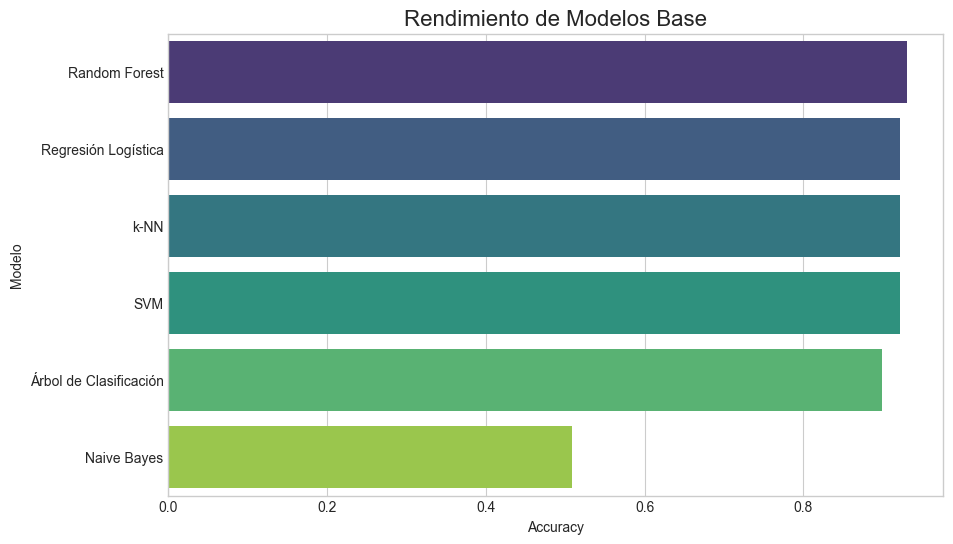

In [32]:
scores_pd_df = pd.DataFrame(list(baseline_scores.items()), columns=['Modelo', 'Accuracy']).sort_values('Accuracy', ascending=False)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Modelo', data=scores_pd_df, palette='viridis', ax=ax)
ax.set_title('Rendimiento de Modelos Base', fontsize=16)
plt.show()

In [33]:
print("\n--- RESUMEN FINAL DE OPTIMIZACIÓN ---")
print(f"Mejor modelo: Random Forest")
print(f"Accuracy en prueba del modelo optimizado: {final_accuracy:.4f}")
print("Hiperparámetros óptimos:\n", best_params_rf)


--- RESUMEN FINAL DE OPTIMIZACIÓN ---
Mejor modelo: Random Forest
Accuracy en prueba del modelo optimizado: 0.9342
Hiperparámetros óptimos:
 {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': True}


## 4. TESTING (../tests/test_utils.py)

In [34]:
%%writefile ../tests/test_utils.py
import pytest
import polars as pl
import pandas as pd
import numpy as np
from unittest.mock import MagicMock
from sklearn.preprocessing import StandardScaler

from src import utils

# --- Fixtures para Pruebas ---
@pytest.fixture
def df_for_splitting() -> pl.DataFrame:
    """Crea un DF predecible para probar la función de división."""
    return pl.DataFrame({
        "feature1": list(range(10)),
        "feature2": list(range(10, 20)),
        "target": [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
    })

@pytest.fixture
def df_with_missing_values() -> pl.DataFrame:
    """Crea un DF con valores nulos para probar el relleno."""
    return pl.DataFrame({
        "col_a": [1.0, 2.0, 3.0, 4.0],
        "col_b_missing": [10.0, 20.0, None, 50.0]
    })

@pytest.fixture
def df_for_dummies() -> pl.DataFrame:
    """Crea un DF con variables categóricas para probar la creación de dummies."""
    return pl.DataFrame({
        "day": ["Mon", "Tue", "Mon"],
        "department": ["sewing", "cutting", "sewing"],
        "team": [1, 2, 1]
    })

@pytest.fixture
def df_with_outlier() -> pl.DataFrame:
    """Crea un DF con un outlier multivariado obvio."""
    return pl.DataFrame({
        "x": [1.0, 1.0, 2.0, 2.0, 1.0, 100.0],
        "y": [1.0, 2.0, 1.0, 2.0, 1.0, 100.0]
    })


# --- Pruebas Unitarias ---

def test_load_and_prepare_data(mocker):
    mock_fetch = mocker.patch('src.utils.fetch_ucirepo')
    mock_features_pd = pd.DataFrame({'date': ['2025-06-11'], 'some_feature': [10]})
    mock_targets_pd = pd.DataFrame({'actual_productivity': [0.8]})
    mock_repo = MagicMock()
    mock_repo.data.features = mock_features_pd
    mock_repo.data.targets = mock_targets_pd
    mock_fetch.return_value = mock_repo
    df = utils.load_and_prepare_data(dataset_id=597, target="actual_productivity", threshold=0.5)
    mock_fetch.assert_called_once_with(id=597)
    assert isinstance(df, pl.DataFrame)
    assert 'date' not in df.columns
    assert df['actual_productivity'][0] == 1
    assert 'some_feature' in df.columns

def test_handle_missing_values(df_with_missing_values):
    df_input = df_with_missing_values
    assert df_input["col_b_missing"].is_null().sum() == 1
    df_filled = utils.handle_missing_values(df_input)
    assert df_filled["col_b_missing"].is_null().sum() == 0
    assert df_filled[2, "col_b_missing"] == 20.0

def test_create_dummies(df_for_dummies):
    """Prueba que las variables categóricas se conviertan a dummies correctamente."""
    df_input = df_for_dummies
    df_dummied = utils.create_dummies(df_input, ["day", "department", "team"])
    
    assert "day" not in df_dummied.columns
    assert "department" not in df_dummied.columns
    
    # --- INICIO DE LA CORRECCIÓN ---
    # El resultado real muestra que para 'department', se crea 'department_cutting'.
    # Ajustamos las aserciones para que coincidan con este comportamiento.
    assert "day_Tue" in df_dummied.columns
    assert "day_Mon" not in df_dummied.columns
    
    # La columna creada es 'department_cutting', no 'department_sewing'.
    assert "department_cutting" in df_dummied.columns
    # Por lo tanto, 'department_sewing' fue la categoría eliminada.
    assert "department_sewing" not in df_dummied.columns
    
    assert "team_2" in df_dummied.columns
    assert "team_1" not in df_dummied.columns
    
    # Verificamos un valor específico en la columna que sí se creó
    assert df_dummied[1, "department_cutting"] == 1
    assert df_dummied[0, "department_cutting"] == 0
    # --- FIN DE LA CORRECCIÓN ---

def test_handle_multivariate_outliers(df_with_outlier):
    df_input = df_with_outlier
    df_cleaned = utils.handle_multivariate_outliers(df_input, contamination=0.15)
    assert df_cleaned.shape[0] < df_input.shape[0]
    assert 100.0 not in df_cleaned.get_column("x")

def test_split_data(df_for_splitting):
    df = df_for_splitting
    X_train, X_test, y_train, y_test = utils.split_data(
        df, 'target', test_size=0.2, random_state=42
    )
    assert isinstance(X_train, np.ndarray) and isinstance(y_test, np.ndarray)
    assert X_train.shape == (8, 2)
    assert X_test.shape == (2, 2)
    assert y_train.shape == (8,)
    assert y_test.shape == (2,)

def test_scale_features():
    X_train = np.array([[1.0, 10.0], [2.0, 20.0], [3.0, 30.0]])
    X_test = np.array([[4.0, 40.0]])
    X_train_s, X_test_s, scaler = utils.scale_features(X_train, X_test)
    assert isinstance(X_train_s, np.ndarray)
    assert isinstance(scaler, StandardScaler)
    assert X_train_s.shape == X_train.shape
    assert X_test_s.shape == X_test.shape
    np.testing.assert_almost_equal(X_train_s.mean(axis=0), [0.0, 0.0])
    np.testing.assert_almost_equal(X_train_s.std(axis=0), [1.0, 1.0])

Overwriting ../tests/test_utils.py


## 5. EJECUCIÓN

In [35]:
!pytest ../ -v

============================= test session starts =============================
platform win32 -- Python 3.13.3, pytest-8.4.0, pluggy-1.6.0 -- c:\Users\AzShet\Documents\Jupyter_LAB\jupyter_projects\5to_ciclo\DataMining\lab13\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\AzShet\Documents\Jupyter_LAB\jupyter_projects\5to_ciclo\DataMining\lab13\Data_Mining-LAB13
plugins: mock-3.14.1
collecting ... collected 6 items

..\tests\test_utils.py::test_load_and_prepare_data PASSED                [ 16%]
..\tests\test_utils.py::test_handle_missing_values PASSED                [ 33%]
..\tests\test_utils.py::test_create_dummies PASSED                       [ 50%]
..\tests\test_utils.py::test_handle_multivariate_outliers PASSED         [ 66%]
..\tests\test_utils.py::test_split_data PASSED                           [ 83%]
..\tests\test_utils.py::test_scale_features PASSED                       [100%]

============================== 6 passed in 3.33s ==============================
